In [2]:
# ============================================================
# Energy Lab 3: Conduction ML Model
# JupyterHub / JupyterLab Version
# ============================================================

In [1]:
# ------------------------------------------------------------
# Section 1: Import Required Libraries
# ------------------------------------------------------------

import os
from pathlib import Path
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Make numpy printouts easier to read
np.set_printoptions(precision=3, suppress=True)

print("TensorFlow version:", tf.__version__)

I0000 00:00:1782848912.798741     212 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782848912.851039     212 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782848914.433870     212 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


In [2]:
import os

# Directory to scan — '.' is the notebook's own folder
directory = '.'

# Get just the file names (skips subdirectories)
file_names = [f for f in os.listdir(directory)
              if os.path.isfile(os.path.join(directory, f))]

# Print them with an index
for i, name in enumerate(file_names):
    print(f"{i}: {name}")

0: Energy_Lab_Conduction.ipynb
1: conduction_100 (1).csv
2: conduction_test (1).csv


In [3]:
# Change this only if your file name is different
DATA_FILE = file_names[1]

if Path(DATA_FILE).exists():
    data = pd.read_csv(DATA_FILE)
    print(f"\nDataset loaded successfully from: {DATA_FILE}")


Dataset loaded successfully from: conduction_100 (1).csv


In [4]:
# ------------------------------------------------------------
# Section 3: Define Inputs and Outputs
# ------------------------------------------------------------

input_cols = ["T0", "T1", "T2", "T3", "T4", "T5"]
output_cols = ["q", "T1*", "T2*", "T3*", "T4*"]

# Check if required columns exist
missing_input_cols = [col for col in input_cols if col not in data.columns]
missing_output_cols = [col for col in output_cols if col not in data.columns]

if missing_input_cols or missing_output_cols:
    print("ERROR: Some required columns are missing.")
    print("Missing input columns:", missing_input_cols)
    print("Missing output columns:", missing_output_cols)
    raise ValueError("Please check your CSV column names.")

print("Input columns:", input_cols)
print("Output columns:", output_cols)

Input columns: ['T0', 'T1', 'T2', 'T3', 'T4', 'T5']
Output columns: ['q', 'T1*', 'T2*', 'T3*', 'T4*']


In [5]:
# ------------------------------------------------------------
# Section 4: Split Data into Training and Test Sets
# ------------------------------------------------------------

train_dataset = data.sample(frac=0.8, random_state=42)
test_dataset = data.drop(train_dataset.index)

print("Training dataset shape:", train_dataset.shape)
print("Testing dataset shape:", test_dataset.shape)

Training dataset shape: (80, 11)
Testing dataset shape: (20, 11)


In [6]:
# ------------------------------------------------------------
# Section 5: Normalize Data
# ------------------------------------------------------------

# Training statistics for normalization
train_stats = train_dataset[input_cols].describe().transpose()

def normalize(df):
    return (df - train_stats["mean"]) / train_stats["std"]

normed_train_data = normalize(train_dataset[input_cols])
normed_test_data = normalize(test_dataset[input_cols])

train_labels = train_dataset[output_cols]
test_labels = test_dataset[output_cols]

print("Normalized training data:")
display(normed_train_data.head())

print("Normalized testing data:")
display(normed_test_data.head())

Normalized training data:


,T0,T1,T2,T3,T4,T5
83,-1.484795,-1.479473,-1.464805,-1.470403,-1.477786,-1.474696
53,-0.058715,-0.056723,-0.075161,-0.073923,-0.071393,-0.076762
70,1.285299,1.287747,1.296013,1.300049,1.306125,1.301035
45,-0.425447,-0.421499,-0.440060,-0.427810,-0.408476,-0.414153
44,-0.068504,-0.071634,-0.078104,-0.084607,-0.095690,-0.086801


Normalized testing data:


,T0,T1,T2,T3,T4,T5
1,0.305988,0.320008,0.308706,0.324073,0.346100,0.325411
2,0.605269,0.619909,0.610583,0.620630,0.634990,0.627307
14,0.188258,0.189222,0.181581,0.181166,0.180514,0.168227
20,0.054053,0.060838,0.036587,0.049846,0.069062,0.050934
21,0.731338,0.754558,0.719676,0.746577,0.785096,0.760312


In [7]:
# ------------------------------------------------------------
# Section 6: Build the Model
# ------------------------------------------------------------

num_outputs = len(output_cols)

baseline_model = keras.Sequential([
    layers.Input(shape=(len(input_cols),)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_outputs)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

baseline_model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae", "mse"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,093 (35.52 KB)

 Trainable params: 9,093 (35.52 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# ------------------------------------------------------------
# Section 7: Define Callback and Training Parameters
# ------------------------------------------------------------

class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 100 == 0:
            print("")
        print(".", end="")

EPOCHS = 1000


# ------------------------------------------------------------
# Section 8: Example Prediction Before Training
# ------------------------------------------------------------

example_batch = normed_train_data[:5].values
example_result = baseline_model.predict(example_batch)

print("Example predictions before training:")
print(pd.DataFrame(example_result, columns=output_cols))


# ------------------------------------------------------------
# Section 9: Setup TensorBoard
# ------------------------------------------------------------

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

print("TensorBoard log directory:", log_dir)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Example predictions before training:
          q       T1*       T2*       T3*       T4*
0 -0.020131  0.102956 -0.030686 -0.124035 -0.170301
1 -0.000387  0.005013 -0.003602 -0.004218 -0.006762
2 -0.222273  0.330001 -0.192626 -0.482159 -0.421935
3 -0.007480  0.030893 -0.005524 -0.032077 -0.048682
4  0.000052  0.005432 -0.005180 -0.007388 -0.008921
TensorBoard log directory: logs/fit/20260630-195142


In [ ]:
# ------------------------------------------------------------
# Section 10: Train the Model
# ------------------------------------------------------------

history = baseline_model.fit(
    normed_train_data.values,
    train_labels.values,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=0,
    callbacks=[PrintDot()]
)

print("\nTraining completed.")


....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
..............................................................................

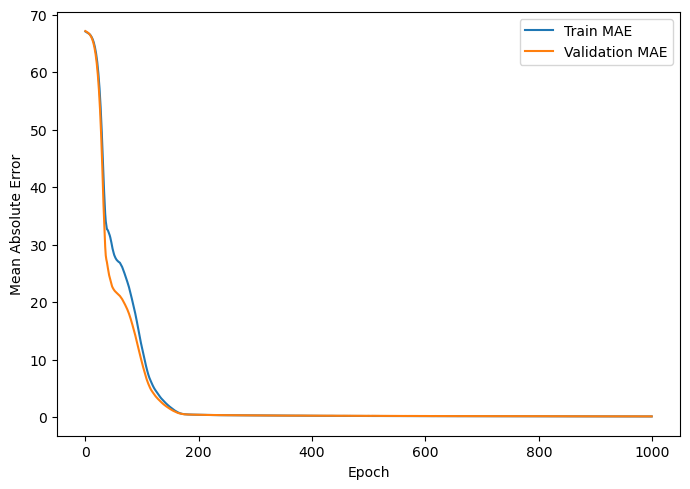

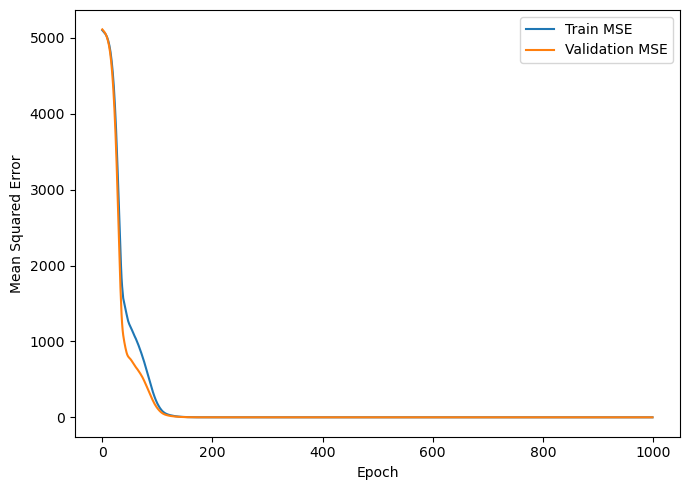

In [13]:
# ------------------------------------------------------------
# Section 11: Plot Training History
# ------------------------------------------------------------

def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist["epoch"] = history.epoch

    # MAE plot
    plt.figure(figsize=(7, 5))
    plt.plot(hist["epoch"], hist["mae"], label="Train MAE")
    plt.plot(hist["epoch"], hist["val_mae"], label="Validation MAE")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Absolute Error")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # MSE plot
    plt.figure(figsize=(7, 5))
    plt.plot(hist["epoch"], hist["mse"], label="Train MSE")
    plt.plot(hist["epoch"], hist["val_mse"], label="Validation MSE")
    plt.xlabel("Epoch")
    plt.ylabel("Mean Squared Error")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Actual vs predicted values:


,Actual q,Actual T1*,Actual T2*,Actual T3*,Actual T4*,Predicted q,Predicted T1*,Predicted T2*,Predicted T3*,Predicted T4*
1,22.482111,88.638000,87.392000,80.073400,63.114700,22.528553,88.465302,87.158997,79.827744,63.041756
2,22.867244,90.171200,88.908300,81.473400,64.198900,22.854618,89.932693,88.599892,81.193718,64.056541
14,22.373118,88.039515,86.748504,79.512795,62.610273,22.430744,88.038475,86.760353,79.439758,62.738792
20,22.180673,87.348664,86.090188,78.835032,62.124287,22.256094,87.340141,86.072556,78.816887,62.212498
21,23.021763,90.816584,89.583459,81.986387,64.658173,22.928225,90.304810,88.968102,81.555756,64.317062


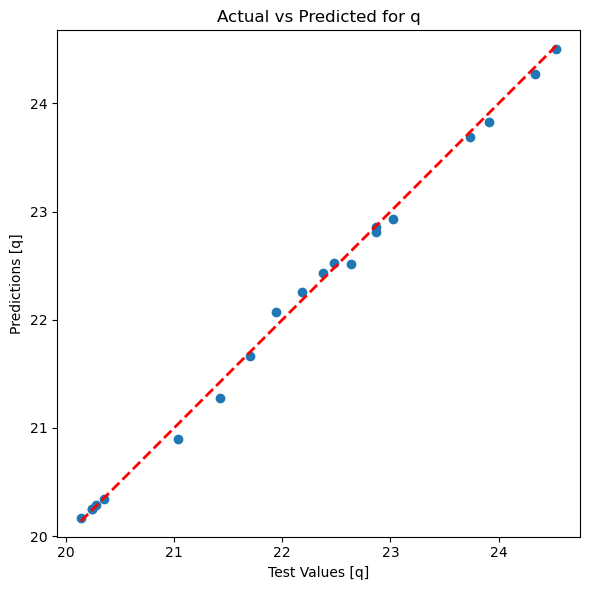

In [14]:
# ------------------------------------------------------------
# Section 12: Test Predictions and Scatter Plot for q
# ------------------------------------------------------------

baseline_test_predictions = baseline_model.predict(normed_test_data.values)

prediction_df = pd.DataFrame(
    baseline_test_predictions,
    columns=[f"Predicted {col}" for col in output_cols],
    index=test_labels.index
)

actual_df = test_labels.copy()
actual_df.columns = [f"Actual {col}" for col in output_cols]

comparison_df = pd.concat([actual_df, prediction_df], axis=1)

print("Actual vs predicted values:")
display(comparison_df.head())

# Scatter plot for q
actual_q = test_labels["q"].values
predicted_q = baseline_test_predictions[:, 0]

min_q = min(actual_q.min(), predicted_q.min())
max_q = max(actual_q.max(), predicted_q.max())

plt.figure(figsize=(6, 6))
plt.scatter(actual_q, predicted_q)
plt.plot([min_q, max_q], [min_q, max_q], "r--", linewidth=2)
plt.xlabel("Test Values [q]")
plt.ylabel("Predictions [q]")
plt.title("Actual vs Predicted for q")
plt.axis("equal")
plt.tight_layout()
plt.show()


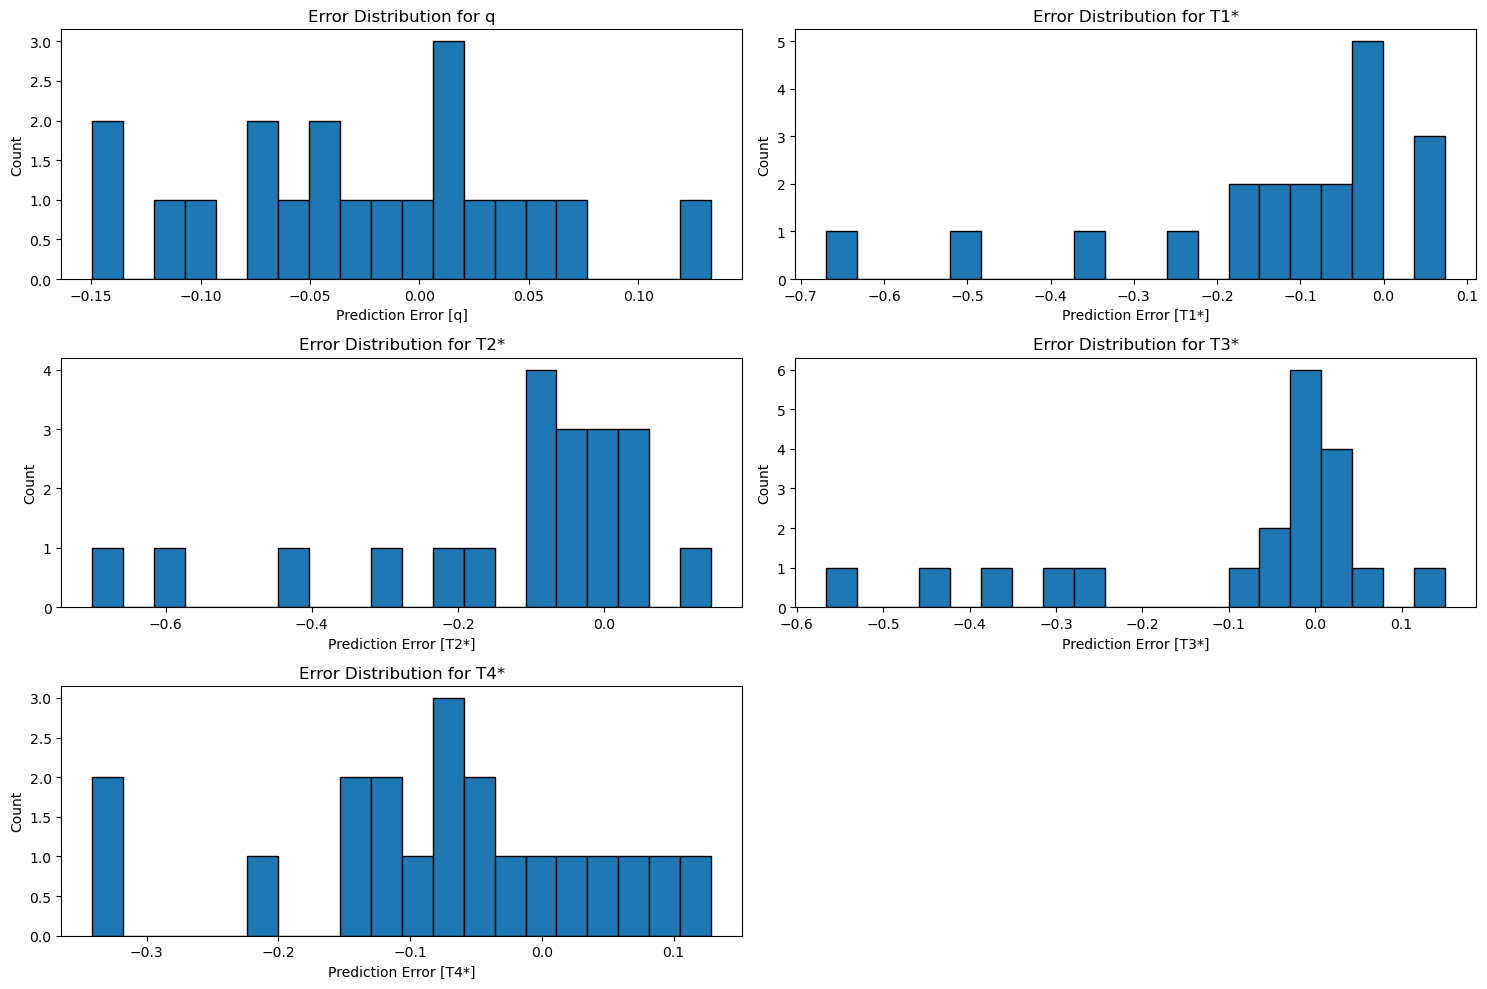

In [15]:
# ------------------------------------------------------------
# Section 13: Prediction Error Histograms
# ------------------------------------------------------------

baseline_error = baseline_test_predictions - test_labels.values

plt.figure(figsize=(15, 10))

for i, name in enumerate(output_cols):
    plt.subplot(3, 2, i + 1)
    plt.hist(baseline_error[:, i], bins=20, edgecolor="black")
    plt.xlabel(f"Prediction Error [{name}]")
    plt.ylabel("Count")
    plt.title(f"Error Distribution for {name}")

plt.tight_layout()
plt.show()


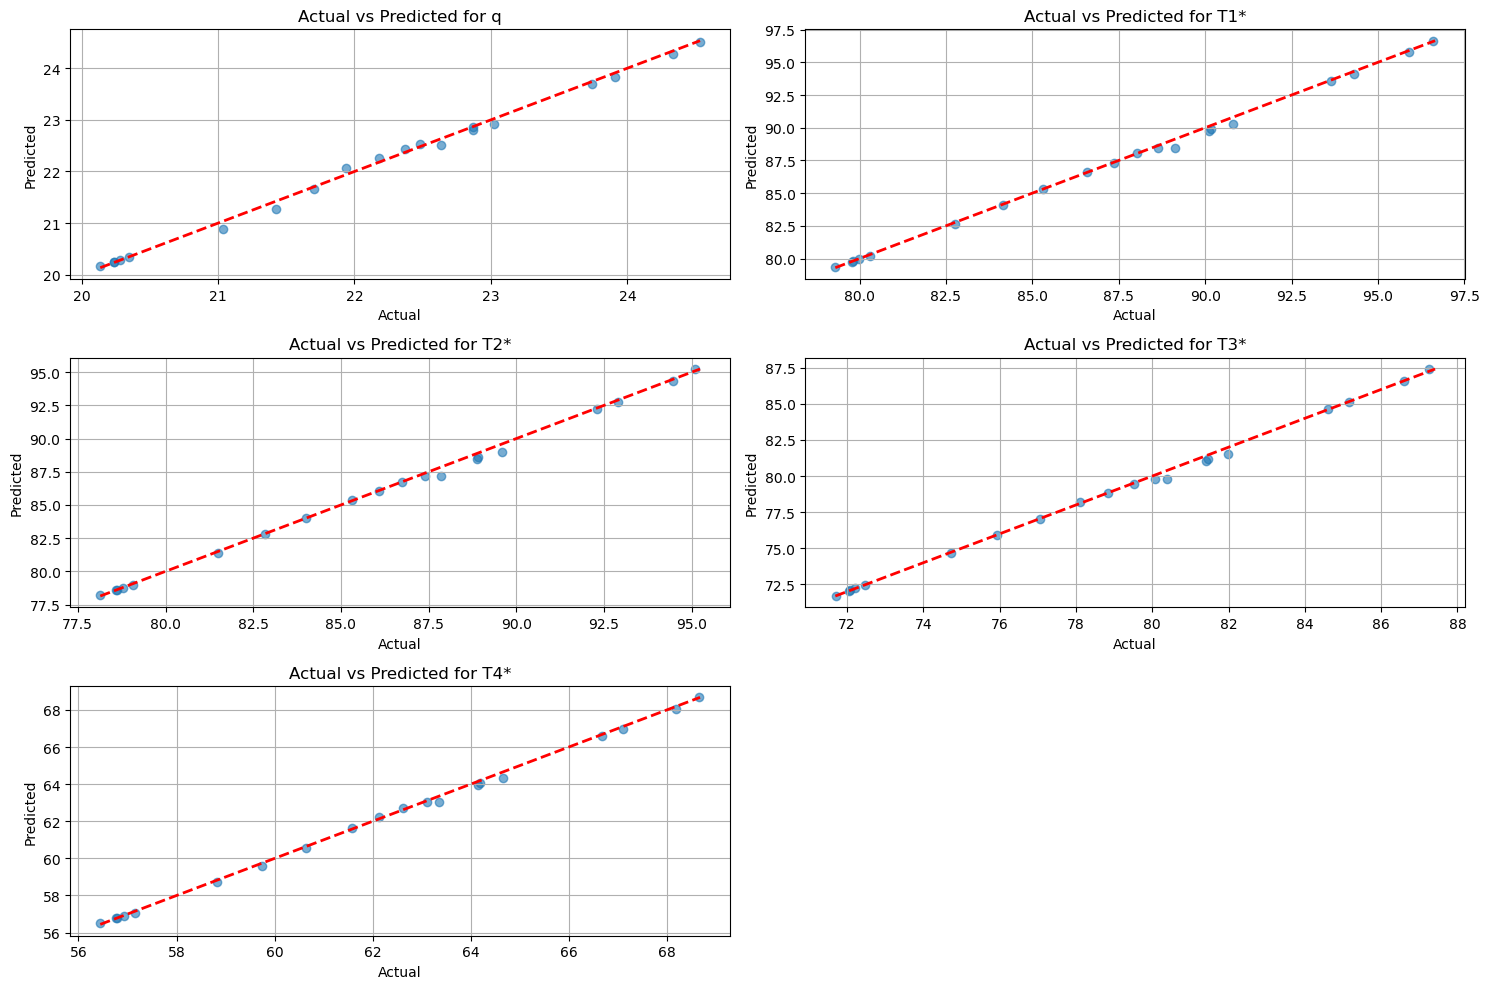

In [16]:
# ------------------------------------------------------------
# Section 14: Actual vs Predicted Plot for All Outputs
# ------------------------------------------------------------

plt.figure(figsize=(15, 10))

for i, name in enumerate(output_cols):
    actual = test_labels[name].values
    predicted = baseline_test_predictions[:, i]

    min_val = min(actual.min(), predicted.min())
    max_val = max(actual.max(), predicted.max())

    plt.subplot(3, 2, i + 1)
    plt.scatter(actual, predicted, alpha=0.6)
    plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Actual vs Predicted for {name}")
    plt.grid(True)

plt.tight_layout()
plt.show()


In [17]:
# ------------------------------------------------------------
# Section 15: Predict New Data
# ------------------------------------------------------------
# OPTIONAL:
# Upload a new CSV file using the left-side upload button.
# The new CSV should contain only the input columns:
# T0, T1, T2, T3, T4, T5
#
# Then change NEW_INPUT_FILE below to the uploaded file name.
# If you do not want to run this section now, leave the file name as it is.

NEW_INPUT_FILE = "conduction_test.csv"

if Path(NEW_INPUT_FILE).exists():
    new_input = pd.read_csv(NEW_INPUT_FILE)

    print("New input file loaded successfully.")
    print("Shape of new input:", new_input.shape)
    display(new_input.head())

    missing_new_cols = [col for col in input_cols if col not in new_input.columns]

    if missing_new_cols:
        print("ERROR: New input file is missing these columns:")
        print(missing_new_cols)
        raise ValueError("Please check the new input CSV column names.")

    normed_new = (new_input[input_cols] - train_stats["mean"]) / train_stats["std"]
    preds = baseline_model.predict(normed_new.values)

    preds_df = pd.DataFrame(preds, columns=output_cols)

    print("Predictions for new input data:")
    display(preds_df)

    # Save predictions
    OUTPUT_FILE = "new_predictions.csv"
    preds_df.to_csv(OUTPUT_FILE, index=False)

    print(f"Predictions saved as: {OUTPUT_FILE}")

else:
    print("")
    print("Section 15 skipped.")
    print(f"No file named '{NEW_INPUT_FILE}' was found.")
    print("To use this section, upload a new input CSV and update NEW_INPUT_FILE.")


New input file loaded successfully.
Shape of new input: (10, 6)


,T0,T1,T2,T3,T4,T5
0,50,52,54,56,58,60
1,60,63,66,69,72,75
2,70,72,74,76,78,80
3,80,83,86,89,92,95
4,90,92,94,96,98,100


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predictions for new input data:


,q,T1*,T2*,T3*,T4*
0,77.945168,309.635284,308.002655,280.391754,221.772308
1,104.319557,412.959717,410.279205,374.077484,295.893158
2,110.849144,439.058502,435.410217,397.812408,313.926910
3,139.254532,552.494812,547.534180,500.736023,394.245239
4,146.137665,580.715698,575.232178,526.422363,414.099213
5,164.286545,653.832581,647.405823,592.774780,465.967896
6,193.894791,772.406433,764.535034,700.248596,550.256592
7,201.304062,802.991699,794.433533,727.899536,571.844238
8,231.085541,922.553894,912.558411,836.256104,656.858582
9,239.211716,956.353577,945.870117,866.997559,680.796021


Predictions saved as: new_predictions.csv


In [18]:
# ------------------------------------------------------------
# Section 16: Save Trained Model
# ------------------------------------------------------------

MODEL_FILE = "energy_lab_3_conduction_model.keras"
baseline_model.save(MODEL_FILE)

print(f"Trained model saved as: {MODEL_FILE}")

Trained model saved as: energy_lab_3_conduction_model.keras
